# Comparación Few-Shot: v1 vs v2 vs v3 vs v4_principle

Este notebook compara las **cuatro iteraciones** del prompt aplicadas al modelo `qwen2.5:14b` sobre el mismo subset de validación humana.

> **Nota**: el v4 original (Soft Few-Shot interpretativo) se ha excluido de este análisis porque su CSV salió todo vacío (el modelo no estaba descargado en Ollama durante esa ejecución y el runner devolvía 404 sin avisar). El v4_principle es la versión que reemplaza al v4.

## ¿Qué se compara?

| Versión | Filosofía del prompt | Ficha rápida |
|---|---|---|
| **v1** | Few-Shot contrastivo (muchos ejemplos rígidos Q→A). | Aprende a imitar más que a razonar. Riesgo: efecto loro. |
| **v2** | Zero-Shot con Chain-of-Thought + algoritmo deductivo imperativo. | Mandatory checklist, "Step 1...". Riesgo: obediencia mecánica. |
| **v3** | v2 + filtro background-vs-focus + re-verify social/policy. | Refuerzo del veredicto None. Riesgo: parsimonia excesiva. |
| **v4_principle** | Principle-Driven con etiquetas XML + 3 calibration cases. | Estructura clara (XML), reglas de confusión explícitas. **Es la propuesta que estamos validando.** |

## Cómo leer este notebook

Cada sección incluye:
1. La métrica/visualización.
2. **Cómo se calcula**: definición operativa.
3. **Cómo interpretarla**: qué te está diciendo de verdad sobre el modelo.
4. **Qué buscar**: el patrón saludable y el patrón sospechoso.

## Subset de evaluación

- 146 documentos (208 validados − 3 ejemplos del prompt v4_principle − 59 que no estaban en el corpus).
- Cruzados con todas las versiones disponibles → comparación apples-to-apples.
- Ground-truth multi-etiqueta: cada documento puede tener `1stpb`, `2ndpb`, `3rdpb`.
- Los 3 docs excluidos por aparecer en el prompt v4_principle: `b9e1bf330baf`, `9153f4dcf3d6`, `f21bc832abc6`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Mapping versión -> CSV. Si añades una versión nueva, basta tocar aquí.
FILE_MAP = {
    'v1':           'qwen2.5_14b_fewshot_v1.csv',
    'v2':           'qwen2.5_14b_fewshot_v2.csv',
    'v3':           'qwen2.5_14b_fewshot_v3.csv',
    'v4_principle': 'qwen2.5_14b_fewshot_v4_principle.csv',
}
COLORS = {
    'v1': '#9C9C9C',
    'v2': '#4C72B0',
    'v3': '#DD8452',
    'v4_principle': '#55A868',
}
EXAMPLE_DOC_IDS = {'b9e1bf330baf', '9153f4dcf3d6', 'f21bc832abc6'}
PB_LABELS = ['None'] + [f'PB{i}' for i in range(1, 10)]
HUMAN_COLS = ['1stpb', '2ndpb', '3rdpb']

## 1. Carga de datos

Cargamos cada CSV de inferencia y el ground-truth humano. Excluimos del eval los 3 docs que aparecen como ejemplos en el prompt v4_principle, para no medir memorización.

La columna `is_empty` marca filas con reasoning vacío (típicamente fallos de ejecución en los que Ollama devolvió error). Si alguna versión tiene mucho `is_empty`, sus métricas no son comparables y conviene re-ejecutar el runner.

In [2]:
LLM_DIR = Path.cwd().resolve().parent
INF_DIR = LLM_DIR / 'outputs' / 'inferences'
GT_DIR = LLM_DIR / 'outputs' / 'ground_truth'

df_human = pd.read_csv(GT_DIR / 'validacion_real.csv', sep=';', encoding='utf-8')
df_human.columns = df_human.columns.str.strip().str.lower()
df_human['doc_id'] = df_human['doc_id'].astype(str).str.strip()

dfs = {}
for v, fname in FILE_MAP.items():
    p = INF_DIR / fname
    if p.exists():
        d = pd.read_csv(p, keep_default_na=False)
        d['doc_id'] = d['doc_id'].astype(str).str.strip()
        # Marca filas claramente vacías (errores) para poder filtrarlas si quieres
        d['is_empty'] = (d['llm_primary_pb'].isin(['None', '', 'Error'])) & (d['llm_reasoning'] == '')
        dfs[v] = d
        empty = d['is_empty'].sum()
        print(f'{v:14s}: {len(d):3d} filas | reasoning vacío en {empty} (ejecuciones fallidas)')
    else:
        print(f'{v:14s}: archivo no encontrado ({p})')

available = list(dfs.keys())

v1            : 149 filas | reasoning vacío en 0 (ejecuciones fallidas)
v2            : 149 filas | reasoning vacío en 0 (ejecuciones fallidas)
v3            : 149 filas | reasoning vacío en 0 (ejecuciones fallidas)
v4_principle  : 146 filas | reasoning vacío en 0 (ejecuciones fallidas)


## 2. Normalización de etiquetas

Tanto el humano como el LLM expresan las PBs de formas distintas. Aquí las llevamos a un formato común.

**Humano** (`validacion_real.csv`):
- Tiene 3 columnas: `1stpb`, `2ndpb`, `3rdpb`.
- Cada celda puede ser un número (`1`, `4`), un código (`PB1`), o vacío.
- Convertimos todo a la lista `[PBx, PBy, ...]`. Si todas están vacías, la lista es `['None']`.

**LLM**:
- Tiene `llm_primary_pb` (string) y `llm_secondary_pbs` (string separado por comas).
- Los unimos en una sola lista, eliminando duplicados.

**Resultado por documento**: dos listas comparables.
- `human_pbs`: lo que el humano dijo (multi-etiqueta).
- `pbs_<versión>`: lo que cada versión del LLM dijo.

In [3]:
def parse_human_pbs(row):
    pbs = []
    for col in HUMAN_COLS:
        if col not in row.index: continue
        val = str(row[col]).strip()
        if val.lower() in ['nan', 'none', '']: continue
        if val.endswith('.0'): val = val[:-2]
        if val.isdigit(): pbs.append(f'PB{val}')
        elif val.upper().startswith('PB'): pbs.append(val.upper())
    return pbs if pbs else ['None']

def parse_llm_pbs(prim, sec):
    pbs = []
    if isinstance(prim, str) and prim.strip() and prim.strip() not in ['None', 'Error', '']:
        pbs.append(prim.strip())
    if isinstance(sec, str) and sec.strip().lower() not in ['none', 'nan', '', 'error']:
        for s in sec.split(','):
            s = s.strip()
            if s and s not in pbs: pbs.append(s)
    return pbs if pbs else ['None']

df_human['human_pbs'] = df_human.apply(parse_human_pbs, axis=1)
df_human['human_primary'] = df_human['human_pbs'].apply(lambda x: x[0])

merged = df_human[['doc_id', 'human_pbs', 'human_primary']].copy()
merged = merged[~merged['doc_id'].isin(EXAMPLE_DOC_IDS)].copy()

for v in available:
    d = dfs[v].copy()
    d['llm_pbs'] = d.apply(lambda r: parse_llm_pbs(r['llm_primary_pb'], r['llm_secondary_pbs']), axis=1)
    d['llm_primary'] = d['llm_primary_pb'].replace('', 'None').replace('Error', 'None')
    cols = ['doc_id', 'llm_pbs', 'llm_primary', 'inference_time_sec']
    if 'llm_reasoning' in d.columns:
        cols.append('llm_reasoning')
    if 'llm_primary_conf' in d.columns:
        cols.append('llm_primary_conf')
    d = d[cols].rename(columns={
        'llm_pbs': f'pbs_{v}',
        'llm_primary': f'prim_{v}',
        'inference_time_sec': f'time_{v}',
        'llm_reasoning': f'reason_{v}',
        'llm_primary_conf': f'conf_{v}',
    })
    merged = merged.merge(d, on='doc_id', how='inner')

print(f'Documentos cruzados con todas las versiones: {len(merged)}')
print()
print('Distribución del ground-truth humano:')
print(f"  None (sin PB):                 {(merged['human_primary'] == 'None').sum():3d}")
print(f"  Solo primario:                 {merged['human_pbs'].apply(lambda x: len(x) == 1 and x[0] != 'None').sum():3d}")
print(f"  Primario + 1 secundario:       {merged['human_pbs'].apply(lambda x: len(x) == 2).sum():3d}")
print(f"  Primario + 2 secundarios:      {merged['human_pbs'].apply(lambda x: len(x) == 3).sum():3d}")

Documentos cruzados con todas las versiones: 147

Distribución del ground-truth humano:
  None (sin PB):                  50
  Solo primario:                  65
  Primario + 1 secundario:        32
  Primario + 2 secundarios:        0


## 3. Glosario de métricas

Antes de mirar los números, fija el sentido de cada métrica. La elección de métrica **importa más que el valor**: cada una mide algo distinto, y unas son más justas que otras dada la naturaleza del ground-truth.

### Métricas estrictas

Asumen una sola etiqueta correcta por documento (la `human_primary`).

- **Top-1 estricto** = `(human_primary == llm_primary).mean()`
  - *Lectura literal*: ¿el LLM acertó EXACTAMENTE el PB principal?
  - *Cuándo es justa*: si crees que el primario humano es la verdad indiscutible.
  - *Cuándo es injusta*: si el LLM eligió un PB que el humano sí etiquetó pero como secundario. Penaliza acuerdos válidos.

### Métricas relajadas (multi-etiqueta)

Reconocen que el GT humano es multi-etiqueta y miden coincidencia parcial.

- **Top-1 relajado** = `mean(llm_primary ∈ human_pbs)`
  - *Lectura*: el LLM eligió como primario ALGÚN PB que el humano también listó.
  - *Por qué importa*: si humano dijo `[PB1, PB4]` y LLM dijo `PB4`, en estricto cuenta como fallo, en relajado como acierto.

- **Hit@K** = `mean(human_primary ∈ llm_pbs)` *sobre los docs donde humano≠None*
  - *Lectura*: el primario humano aparece en algún sitio (primario o secundario) del LLM.
  - *Mide*: capacidad de **no perder** el PB importante, aunque no lo priorice.

- **Any overlap** = `mean(set(human) ∩ set(llm) ≠ ∅)`
  - *Lectura*: hay AL MENOS un PB en común entre humano y LLM.
  - *Es el equivalente más laxo a "estuvieron de acuerdo en algo"*.

- **Jaccard** = `|H ∩ L| / |H ∪ L|`
  - *Lectura*: solapamiento gradual entre las dos listas (0 = ninguno, 1 = idénticas).
  - *Mide*: alineación general en multi-label, mejor que Exact Match para visualizar mejoras parciales.

- **Exact Match** = `mean(set(H) == set(L))`
  - *Lectura*: las dos listas son idénticas como conjuntos.
  - *Es la métrica más estricta posible en multi-label*.

### Métricas de sesgo / calibración

Diagnósticos de comportamiento, no de acierto puro.

- **True Negative rate** = `(human=None & llm=None) / (humanos=None)`
  - *Mide la "rigorosidad"*: cuando el humano dice "este paper no toca PBs", ¿el LLM se abstiene también?
  - *Saludable*: alto (>70%).
  - *Bajo*: el LLM **inventa PBs** en papers de tema irrelevante.

- **Positivity Bias** = `(human=None & llm≠None) / (humanos=None)`
  - *Es 1 − True Negative*. Lo mostramos por separado para legibilidad.

- **Falsos negativos** = `(human≠None & llm=None) / (humanos≠None)`
  - *Lo opuesto*: el LLM dice None cuando el humano sí asignó un PB.
  - *Bajo*: el LLM no se acobarda. *Alto*: prompt demasiado restrictivo.

### Métricas de comportamiento

- **Avg PBs/doc**: cuántos PBs etiqueta de media el LLM. Comparar con humano (~0.7) revela over/under-assignment.
- **Tiempo de inferencia (s)**: latencia por petición. Útil para evaluar coste.

### Cómo elegir la métrica "principal"

- Si quieres un único número para vender la mejora: **Jaccard** o **Any overlap**.
- Si quieres separar acierto de sesgo: usa **Top-1 relajado + True Negative + Positivity Bias** juntas.
- **Top-1 estricto** úsalo solo como referencia comparativa; suele subestimar el modelo.

## 4. Tabla maestra de métricas

Una tabla para gobernarlas a todas. Lee verticalmente: para cada versión, todas las métricas. Lee horizontalmente: para cada métrica, qué versión gana.

El degradado de color marca el ganador por fila (verde) y el peor (rojo).

In [4]:
def metrics_for(v, df):
    top1_strict = (df['human_primary'] == df[f'prim_{v}']).mean()
    top1_relaxed = sum(p in h for p, h in zip(df[f'prim_{v}'], df['human_pbs'])) / len(df)
    none_h = df[df['human_primary'] == 'None']
    non_none = df[df['human_primary'] != 'None']
    hit_at_k = sum(r['human_primary'] in r[f'pbs_{v}'] for _, r in non_none.iterrows()) / max(len(non_none), 1)
    any_overlap = sum(bool(set(h) & set(l)) for h, l in zip(df['human_pbs'], df[f'pbs_{v}'])) / len(df)
    exact = sum(set(r['human_pbs']) == set(r[f'pbs_{v}']) for _, r in df.iterrows()) / len(df)
    jacc = np.mean([len(set(h) & set(l)) / max(len(set(h) | set(l)), 1) for h, l in zip(df['human_pbs'], df[f'pbs_{v}'])])
    true_neg = ((df['human_primary'] == 'None') & (df[f'prim_{v}'] == 'None')).sum() / max(len(none_h), 1)
    pos_bias = ((df['human_primary'] == 'None') & (df[f'prim_{v}'] != 'None')).sum() / max(len(none_h), 1)
    false_neg = ((df['human_primary'] != 'None') & (df[f'prim_{v}'] == 'None')).sum() / max(len(non_none), 1)
    avg_pbs = df[f'pbs_{v}'].apply(lambda x: len([p for p in x if p != 'None'])).mean()
    return {
        'Top-1 estricto':       top1_strict,
        'Top-1 relajado':       top1_relaxed,
        'Hit@K':                hit_at_k,
        'Any overlap':          any_overlap,
        'Exact Match':          exact,
        'Jaccard':              jacc,
        'True Negative':        true_neg,
        'Positivity Bias':      pos_bias,
        'Falsos Negativos':     false_neg,
        'Avg PBs/doc':          avg_pbs,
        'Tiempo medio (s)':     df[f'time_{v}'].mean(),
    }

table = pd.DataFrame({v: metrics_for(v, merged) for v in available})

# Las métricas donde más es mejor vs menos es mejor
LOWER_IS_BETTER = {'Positivity Bias', 'Falsos Negativos', 'Tiempo medio (s)'}

def color_row(row):
    name = row.name
    if name == 'Avg PBs/doc':
        return ['' for _ in row]  # esta es informativa, no hay "mejor"
    vals = row.values
    cmap = 'RdYlGn_r' if name in LOWER_IS_BETTER else 'RdYlGn'
    norm = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)
    if name in LOWER_IS_BETTER: norm = 1 - norm
    return [f'background-color: rgba({int(255*(1-x))}, {int(255*x)}, 100, 0.4)' for x in norm]

display(table.style.format('{:.3f}').apply(color_row, axis=1))

,v1,v2,v3,v4_principle
Top-1 estricto,0.585,0.639,0.646,0.721
Top-1 relajado,0.626,0.673,0.667,0.762
Hit@K,0.505,0.722,0.619,0.742
Any overlap,0.639,0.687,0.680,0.776
Exact Match,0.531,0.503,0.524,0.605
Jaccard,0.581,0.594,0.596,0.688
True Negative,0.840,0.540,0.780,0.760
Positivity Bias,0.160,0.460,0.220,0.240
Falsos Negativos,0.412,0.124,0.289,0.144
Avg PBs/doc,0.592,0.823,0.646,0.769


### Cómo leer la tabla

- **Verde** = mejor para esa métrica. **Rojo** = peor.
- Métricas donde más es mejor: Top-1 estricto/relajado, Hit@K, Any overlap, Exact Match, Jaccard, True Negative.
- Métricas donde menos es mejor: **Positivity Bias**, **Falsos Negativos**, **Tiempo**. (Coloreadas en sentido inverso para que verde siga siendo "mejor").
- **Avg PBs/doc** es informativa, no hay "mejor" objetivo: compáralo con el promedio humano (~0.7) para ver si el LLM sobre/sub-etiqueta.

### Patrones que esperar leer aquí

- Si v4_principle gana en **Jaccard, Any overlap, Top-1 relajado** simultáneamente, el prompt nuevo es Pareto-superior.
- Si gana solo en **True Negative** pero pierde en **Falsos Negativos**, se ha pasado de conservador.
- Si gana en estrictas pero pierde en relajadas, sospechoso: probablemente está acertando primarios pero olvidando secundarios.

## 5. Visualización de métricas clave

Las mismas métricas pero en barras, para captar de un vistazo dónde está cada versión. Una versión saludable tiene barras altas en las métricas de acierto y bajas en las de sesgo.

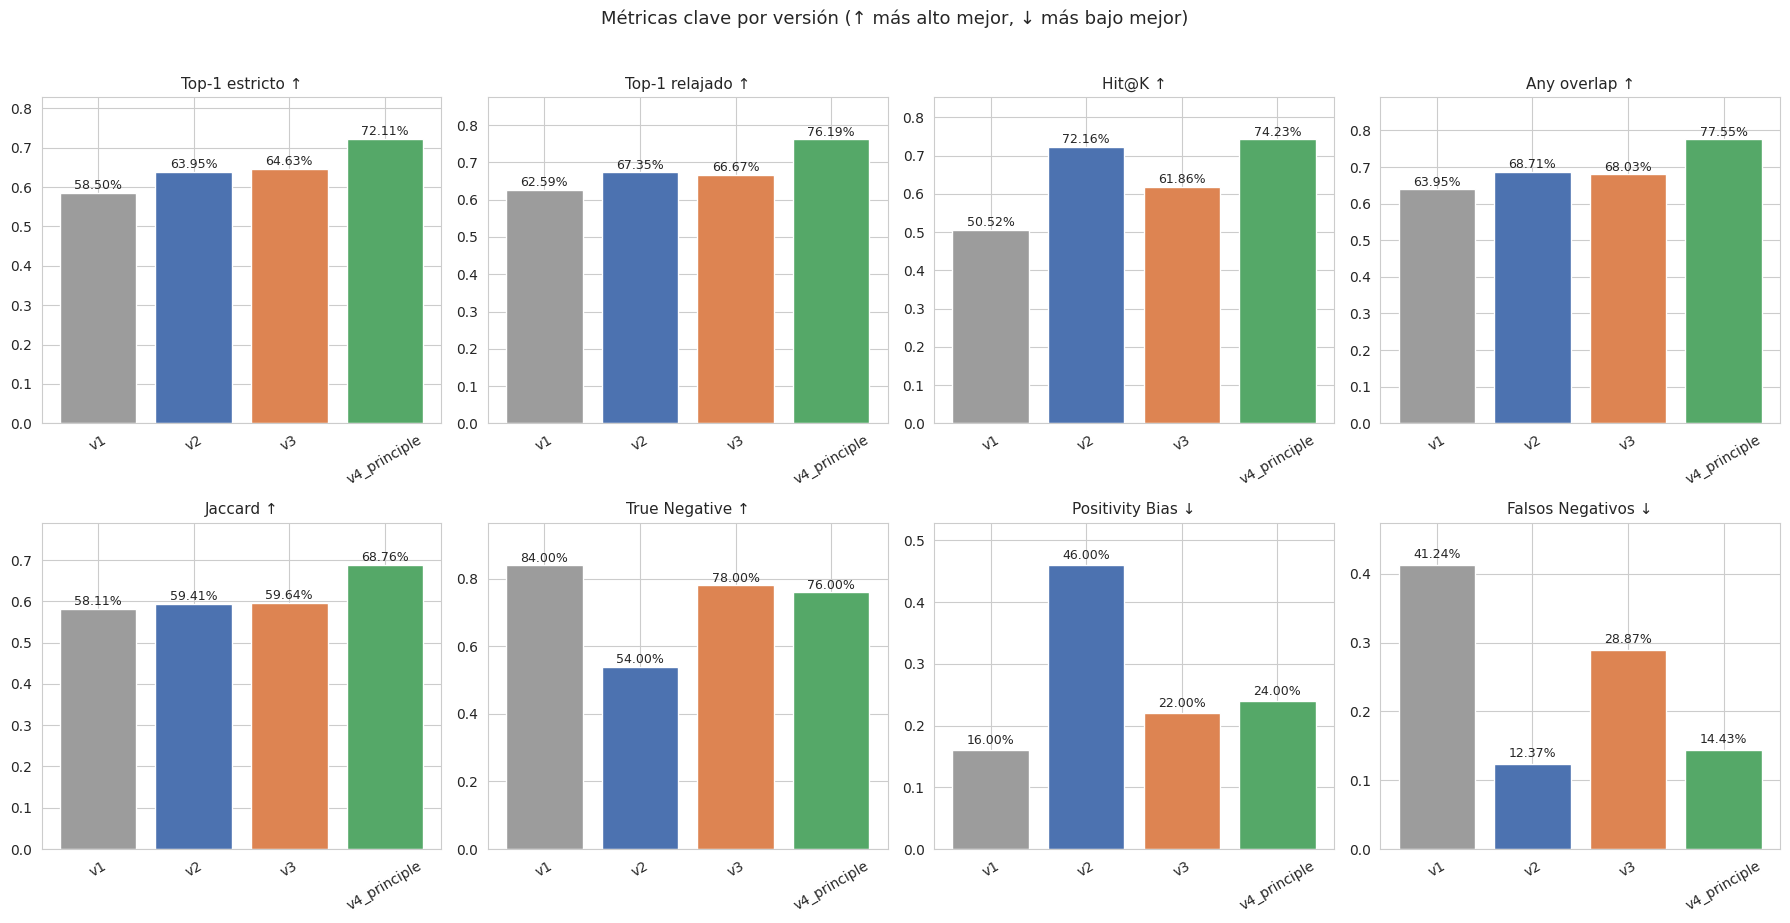

In [5]:
key_metrics = [
    ('Top-1 estricto', False),
    ('Top-1 relajado', False),
    ('Hit@K', False),
    ('Any overlap', False),
    ('Jaccard', False),
    ('True Negative', False),
    ('Positivity Bias', True),
    ('Falsos Negativos', True),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for i, (m, lower_better) in enumerate(key_metrics):
    ax = axes[i // 4, i % 4]
    vals = [table.loc[m, v] for v in available]
    bars = ax.bar(available, vals, color=[COLORS[v] for v in available])
    title_suffix = ' ↓' if lower_better else ' ↑'
    ax.set_title(m + title_suffix, fontsize=11)
    ax.set_ylim(0, max(max(vals) * 1.15, 0.05))
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f'{v:.2%}',
                ha='center', fontsize=9)
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Métricas clave por versión (↑ más alto mejor, ↓ más bajo mejor)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 6. Recall por Planetary Boundary

¿Cómo de bien identifica cada versión cada PB individual?

**Recall por PB** = de todos los documentos donde humano dijo PBx, ¿qué proporción el LLM también dijo PBx como primario?

### Por qué importa
- Top-1 global oculta heterogeneidad. Un modelo puede tener 60% de accuracy gracias a clases fáciles y aún así fallar al 100% en PB7.
- PBs raros en el corpus (PB5, PB8) son más vulnerables a colapso.
- Si una versión sube el promedio pero hunde un PB concreto, **NO es Pareto-superior**.

### Qué buscar
- **Diagonal verde**: cada versión idealmente debería tener recall alto en cada PB.
- **Patrón "uniforme alto"**: la versión es robusta.
- **Patrón "spike + valle"**: la versión es buena en algunas clases y nefasta en otras.

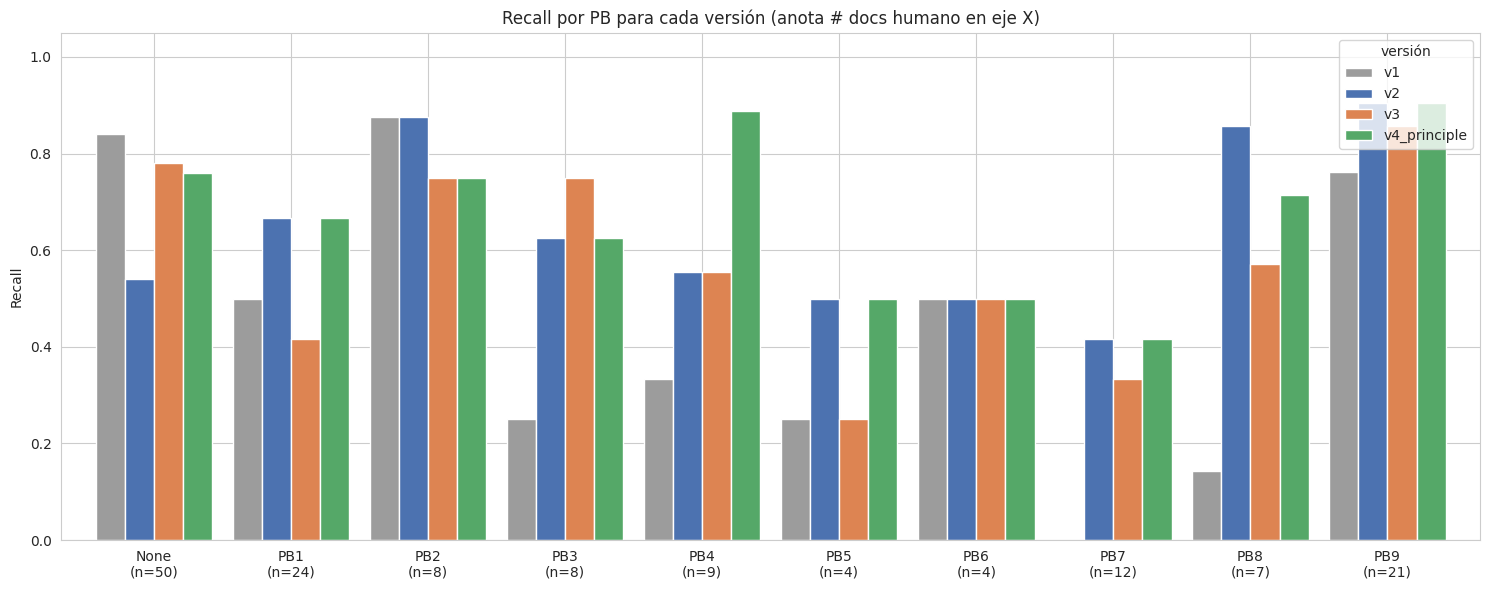

,v1,v2,v3,v4_principle
None,84.00%,54.00%,78.00%,76.00%
PB1,50.00%,66.67%,41.67%,66.67%
PB2,87.50%,87.50%,75.00%,75.00%
PB3,25.00%,62.50%,75.00%,62.50%
PB4,33.33%,55.56%,55.56%,88.89%
PB5,25.00%,50.00%,25.00%,50.00%
PB6,50.00%,50.00%,50.00%,50.00%
PB7,0.00%,41.67%,33.33%,41.67%
PB8,14.29%,85.71%,57.14%,71.43%
PB9,76.19%,90.48%,85.71%,90.48%


In [6]:
recall_data = {}
for pb in PB_LABELS:
    mask = merged['human_primary'] == pb
    if mask.sum() == 0: continue
    recall_data[pb] = {v: (merged.loc[mask, f'prim_{v}'] == pb).mean() for v in available}
    recall_data[pb]['_n_humano'] = int(mask.sum())

recall_df = pd.DataFrame(recall_data).T
n_col = recall_df['_n_humano'].astype(int)
recall_df = recall_df.drop(columns=['_n_humano'])

fig, ax = plt.subplots(figsize=(15, 6))
recall_df.plot(kind='bar', ax=ax, color=[COLORS[v] for v in available], width=0.85)
ax.set_title('Recall por PB para cada versión (anota # docs humano en eje X)')
ax.set_ylabel('Recall'); ax.set_ylim(0, 1.05)
ax.set_xticklabels([f'{pb}\n(n={n_col[pb]})' for pb in recall_df.index], rotation=0)
ax.legend(title='versión', loc='upper right')
plt.tight_layout(); plt.show()

display(recall_df.style.format('{:.2%}').background_gradient(axis=1, cmap='RdYlGn'))

## 7. Matrices de confusión normalizadas

Una matriz de confusión muestra **qué predice el LLM cuando el humano dijo X**. Cada fila suma 1 (proporciones).

### Cómo leerla
- **Diagonal**: aciertos (humano=PBx → LLM=PBx).
- **Columna `None`**: cuando el LLM dice None pero humano dijo otra cosa → **falsos negativos**.
- **Fila `None`**: cuando humano dijo None pero LLM dijo otra cosa → **falsos positivos** (positivity bias).
- **Celdas fuera de diagonal**: confusiones específicas. Un valor alto en `[PB7, PB6]` significa "el LLM confunde PB7 con PB6".

### Qué buscar
- **Diagonal saturada de azul oscuro**: ideal.
- **Columna None demasiado azul**: el LLM se acobarda → muchos falsos negativos.
- **Fila None con celdas azules**: el LLM inventa PBs → positivity bias.
- **Patrones de confusión recurrentes**: pista de qué reglas del prompt fallan.

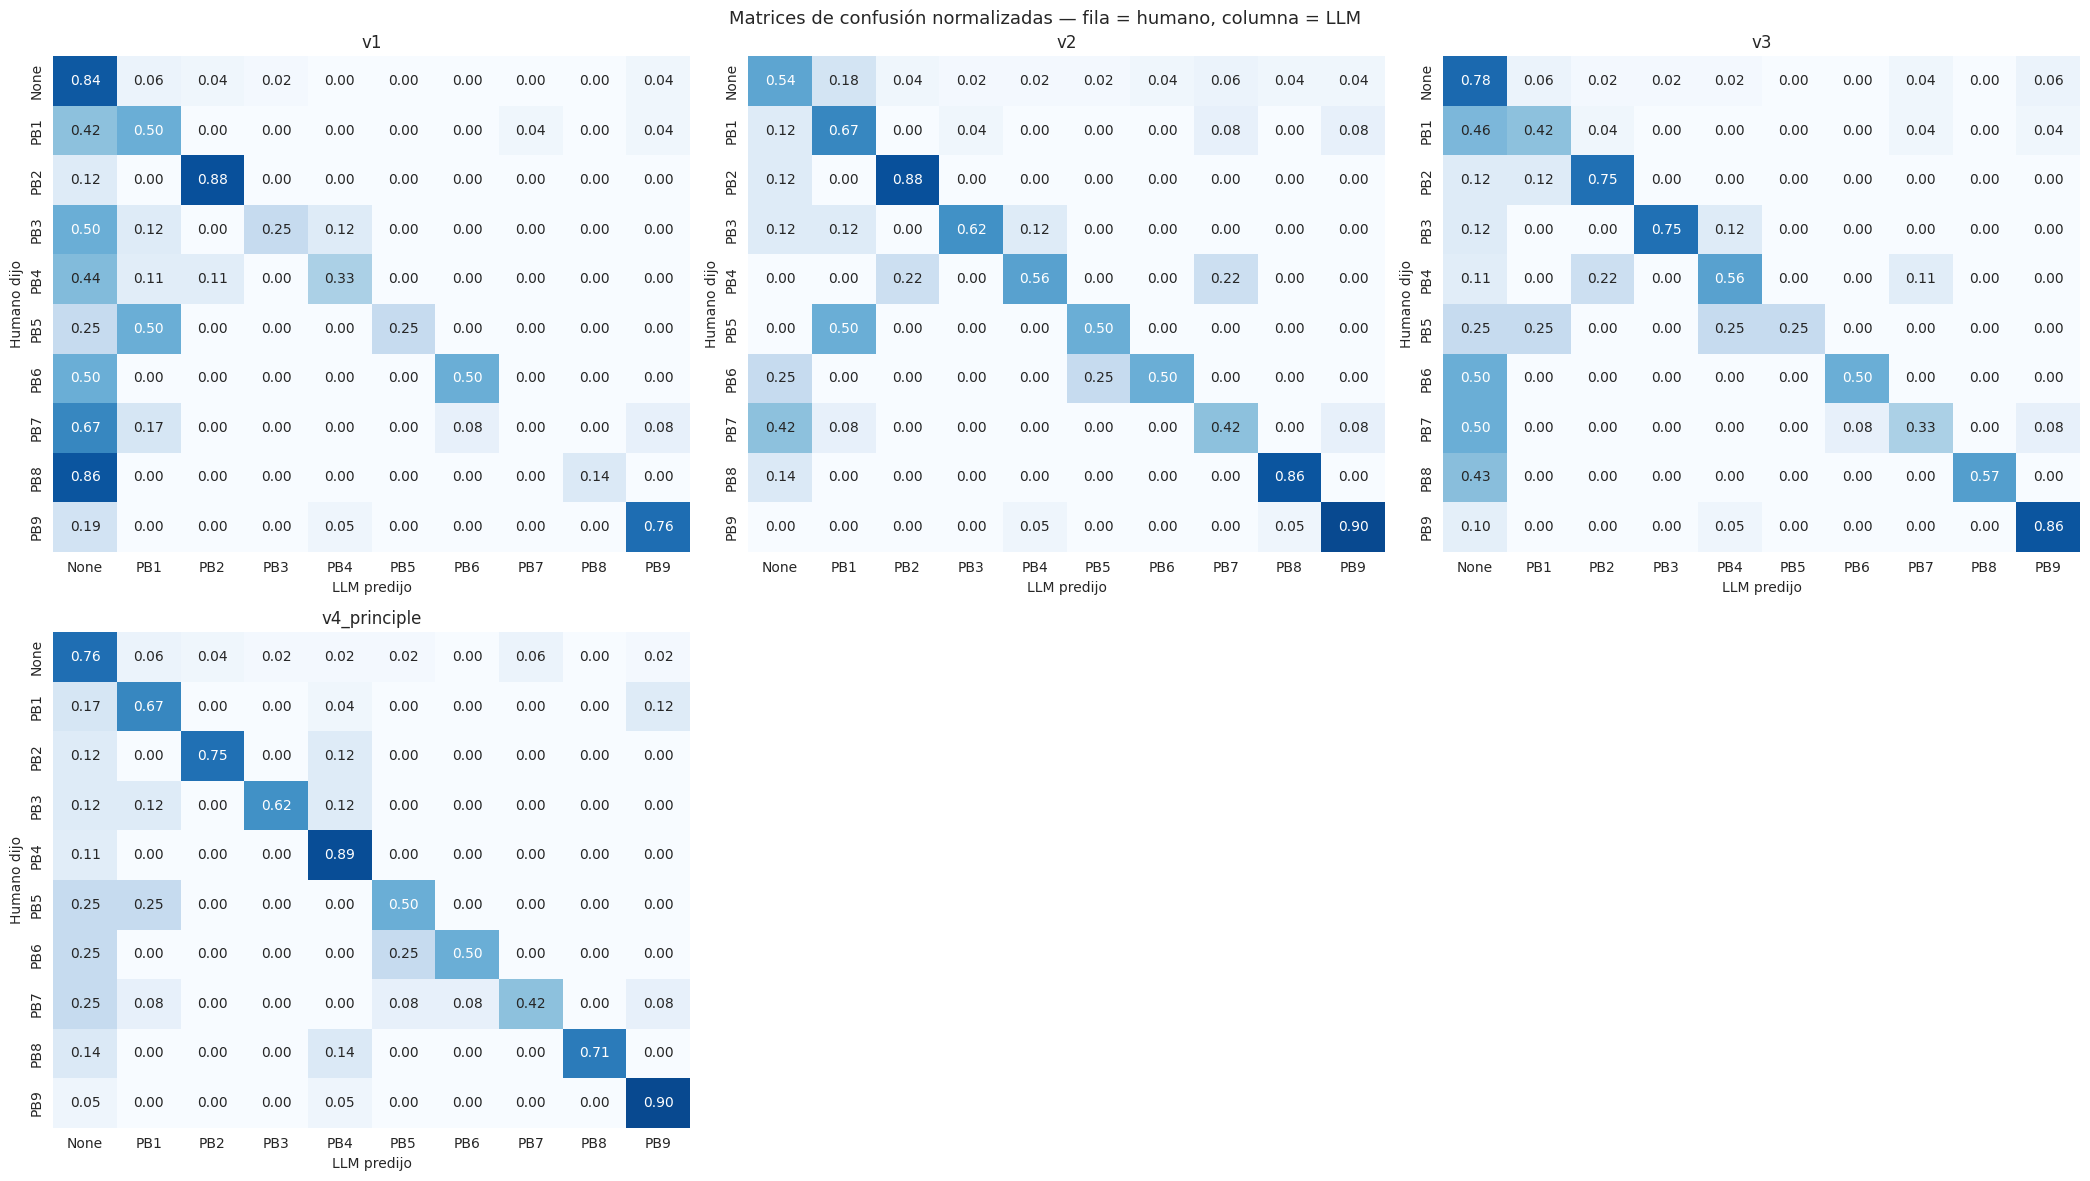

In [7]:
labels = sorted(set(merged['human_primary']) | set().union(*[set(merged[f'prim_{v}']) for v in available]))
labels = [l for l in PB_LABELS if l in labels]

n = len(available)
cols = min(n, 3)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 6 * rows))
axes = np.atleast_2d(axes).flatten()
for ax, v in zip(axes, available):
    cm = confusion_matrix(merged['human_primary'], merged[f'prim_{v}'], labels=labels)
    cm_norm = cm.astype('float') / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax, cbar=False, vmin=0, vmax=1)
    ax.set_xlabel('LLM predijo'); ax.set_ylabel('Humano dijo'); ax.set_title(f'{v}')
for ax in axes[len(available):]:
    ax.set_visible(False)
plt.suptitle('Matrices de confusión normalizadas — fila = humano, columna = LLM', fontsize=13)
plt.tight_layout(); plt.show()

## 8. Modos de fallo: el ying y el yang

Hay dos formas opuestas en que un LLM falla:

1. **Positivity Bias** (humano=None → LLM=PBx): el LLM **inventa** un PB en un paper irrelevante.
2. **Falsos Negativos** (humano=PBx → LLM=None): el LLM **se acobarda** ante un paper que sí toca un PB.

Un buen prompt **minimiza ambos a la vez**. Tirar mucho del filtro None reduce 1 pero dispara 2. Por eso conviene mirarlos juntos.

### 8a. Positivity Bias por versión: ¿qué inventa cuando humano=None?

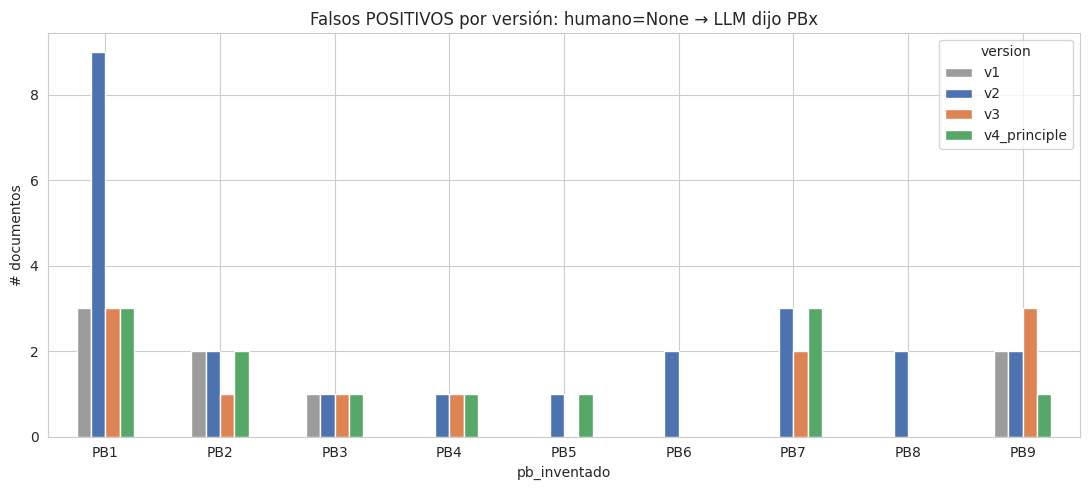

version,v1,v2,v3,v4_principle
pb_inventado,,,,
PB1,3,9,3,3
PB2,2,2,1,2
PB3,1,1,1,1
PB4,0,1,1,1
PB5,0,1,0,1
PB6,0,2,0,0
PB7,0,3,2,3
PB8,0,2,0,0
PB9,2,2,3,1


In [8]:
rows_pb = []
for v in available:
    none_h = merged[merged['human_primary'] == 'None']
    fp = none_h[none_h[f'prim_{v}'] != 'None'][f'prim_{v}'].value_counts()
    for pb, n in fp.items():
        rows_pb.append({'version': v, 'pb_inventado': pb, 'n': n})
fp_df = pd.DataFrame(rows_pb)
if not fp_df.empty:
    pivot = fp_df.pivot(index='pb_inventado', columns='version', values='n').fillna(0).astype(int)
    pivot = pivot.reindex([p for p in PB_LABELS if p in pivot.index])
    fig, ax = plt.subplots(figsize=(11, 5))
    pivot.plot(kind='bar', ax=ax, color=[COLORS[v] for v in pivot.columns])
    ax.set_title('Falsos POSITIVOS por versión: humano=None → LLM dijo PBx')
    ax.set_ylabel('# documentos'); plt.xticks(rotation=0)
    plt.tight_layout(); plt.show()
    display(pivot)
else:
    print('Sin falsos positivos.')

**Lectura**:
- Si el patrón de falsos positivos se concentra en 1-2 PBs (ej: PB1, PB9), es un sesgo sistemático **del prompt**, no del azar. El LLM tiene un "default" en el que cae cuando duda.
- Si los falsos positivos se reparten uniformemente, el problema es más bien que el LLM no detecta bien el "vacío" del paper.

### 8b. Falsos Negativos por versión: ¿qué se le escapa?

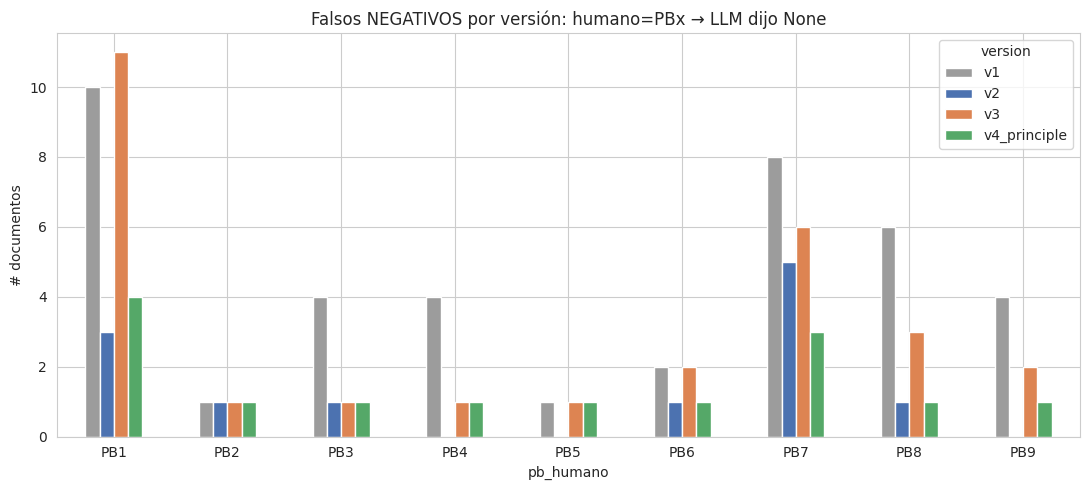

version,v1,v2,v3,v4_principle
pb_humano,,,,
PB1,10,3,11,4
PB2,1,1,1,1
PB3,4,1,1,1
PB4,4,0,1,1
PB5,1,0,1,1
PB6,2,1,2,1
PB7,8,5,6,3
PB8,6,1,3,1
PB9,4,0,2,1


In [9]:
rows_fn = []
for v in available:
    non_none = merged[merged['human_primary'] != 'None']
    fn = non_none[non_none[f'prim_{v}'] == 'None']['human_primary'].value_counts()
    for pb, n in fn.items():
        rows_fn.append({'version': v, 'pb_humano': pb, 'n': n})
fn_df = pd.DataFrame(rows_fn)
if not fn_df.empty:
    pivot = fn_df.pivot(index='pb_humano', columns='version', values='n').fillna(0).astype(int)
    pivot = pivot.reindex([p for p in PB_LABELS if p in pivot.index])
    fig, ax = plt.subplots(figsize=(11, 5))
    pivot.plot(kind='bar', ax=ax, color=[COLORS[v] for v in pivot.columns])
    ax.set_title('Falsos NEGATIVOS por versión: humano=PBx → LLM dijo None')
    ax.set_ylabel('# documentos'); plt.xticks(rotation=0)
    plt.tight_layout(); plt.show()
    display(pivot)
else:
    print('Sin falsos negativos.')

**Lectura**:
- Una columna alta en un PB concreto sugiere que el prompt no expone bien ese PB (vocabulario insuficiente, regla de exclusión demasiado agresiva).
- PB7 y PB8 son típicamente los más vulnerables a falsos negativos: vocabulario diluido y solapamiento conceptual con otros PBs.

### 8c. Top confusiones cruzadas (no involucran None)

In [10]:
rows_cx = []
for v in available:
    err = merged[(merged['human_primary'] != merged[f'prim_{v}']) & 
                 (merged['human_primary'] != 'None') & 
                 (merged[f'prim_{v}'] != 'None')]
    grp = err.groupby(['human_primary', f'prim_{v}']).size().reset_index(name='n')
    for _, rr in grp.iterrows():
        rows_cx.append({'version': v, 'confusion': f"{rr['human_primary']} -> {rr[f'prim_{v}']}", 'n': rr['n']})
cx_df = pd.DataFrame(rows_cx)
if not cx_df.empty:
    top_cx = cx_df.groupby('confusion')['n'].sum().sort_values(ascending=False).head(15).index
    pivot = cx_df[cx_df['confusion'].isin(top_cx)].pivot_table(
        index='confusion', columns='version', values='n', aggfunc='sum').fillna(0).astype(int)
    pivot = pivot.reindex(top_cx)
    display(pivot.style.background_gradient(axis=None, cmap='Reds'))

version,v1,v2,v3,v4_principle
confusion,,,,
PB1 -> PB9,1,2,1,3
PB5 -> PB1,2,2,1,1
PB4 -> PB2,1,2,2,0
PB9 -> PB4,1,1,1,1
PB1 -> PB7,1,2,1,0
PB7 -> PB9,1,1,1,1
PB3 -> PB4,1,1,1,1
PB7 -> PB1,2,1,0,1
PB4 -> PB7,0,2,1,0


**Lectura**: las confusiones cruzadas son las más informativas para iterar el prompt. Si `PB1 → PB9` es persistente, el modelo no distingue clima de aerosoles. Si `PB7 → PB6` se repite, no separa biodiversidad de uso del suelo. Cada confusión sugiere una regla específica de desambiguación que añadir al prompt.

## 9. Distribución de etiquetas asignadas

Compara cuántos PBs etiqueta el LLM en cada doc vs cuántos el humano. Esto revela **over/under-assignment estructural**, independiente de si acierta el PB exacto.

/tmp/ipykernel_1908362/3912286291.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data_long, x='Fuente', y='# PBs', ax=ax, palette=palette, inner='quartile')


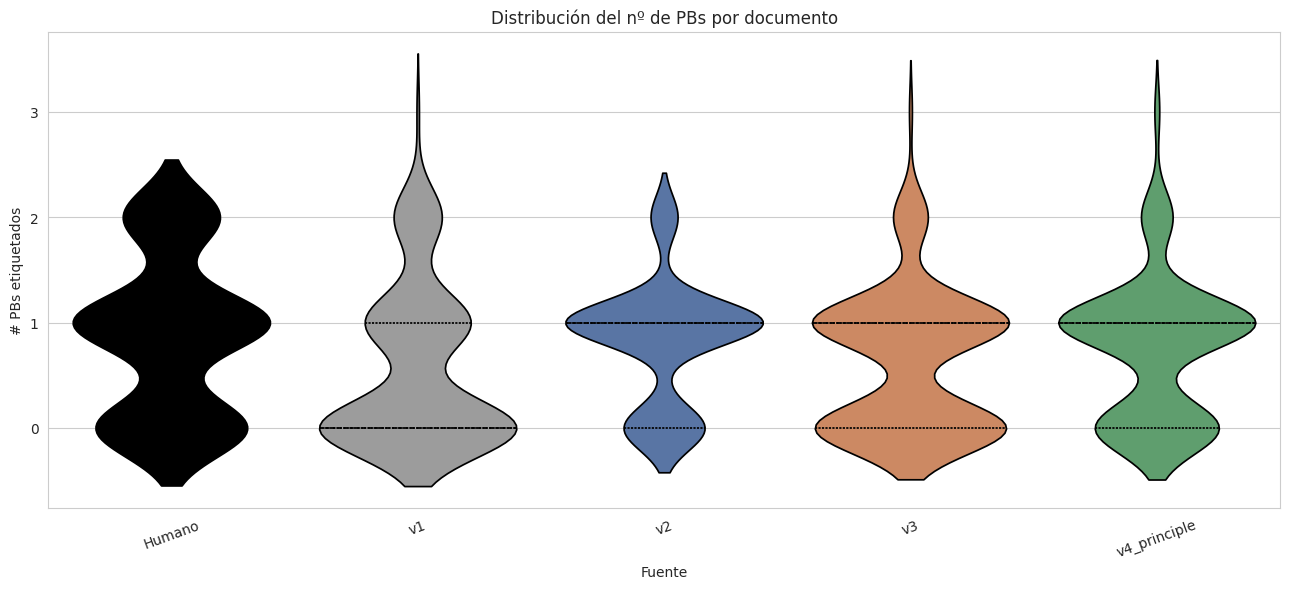

Promedios:
  Humano        : 0.88 PBs/doc
  v1            : 0.59 PBs/doc
  v2            : 0.82 PBs/doc
  v3            : 0.65 PBs/doc
  v4_principle  : 0.77 PBs/doc


In [11]:
human_counts = merged['human_pbs'].apply(lambda x: len([p for p in x if p != 'None']))
data_overassign = pd.DataFrame({'Humano': human_counts})
for v in available:
    data_overassign[v] = merged[f'pbs_{v}'].apply(lambda x: len([p for p in x if p != 'None']))

fig, ax = plt.subplots(figsize=(13, 6))
data_long = data_overassign.melt(var_name='Fuente', value_name='# PBs')
palette = ['black'] + [COLORS[v] for v in available]
sns.violinplot(data=data_long, x='Fuente', y='# PBs', ax=ax, palette=palette, inner='quartile')
ax.set_title('Distribución del nº de PBs por documento')
ax.set_ylabel('# PBs etiquetados'); plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

print('Promedios:')
for col in data_overassign.columns:
    print(f'  {col:14s}: {data_overassign[col].mean():.2f} PBs/doc')

**Lectura**:
- Si el promedio del LLM ≈ 0.7 (humano), está calibrado en cantidad.
- Si el LLM da consistentemente 1.5+ por doc, sobre-etiqueta (probable: confunde "tocar el tema" con "medirlo").
- Si da <0.4, sub-etiqueta (probable: filtro None demasiado agresivo).

### 9b. Distribución de PBs primarios

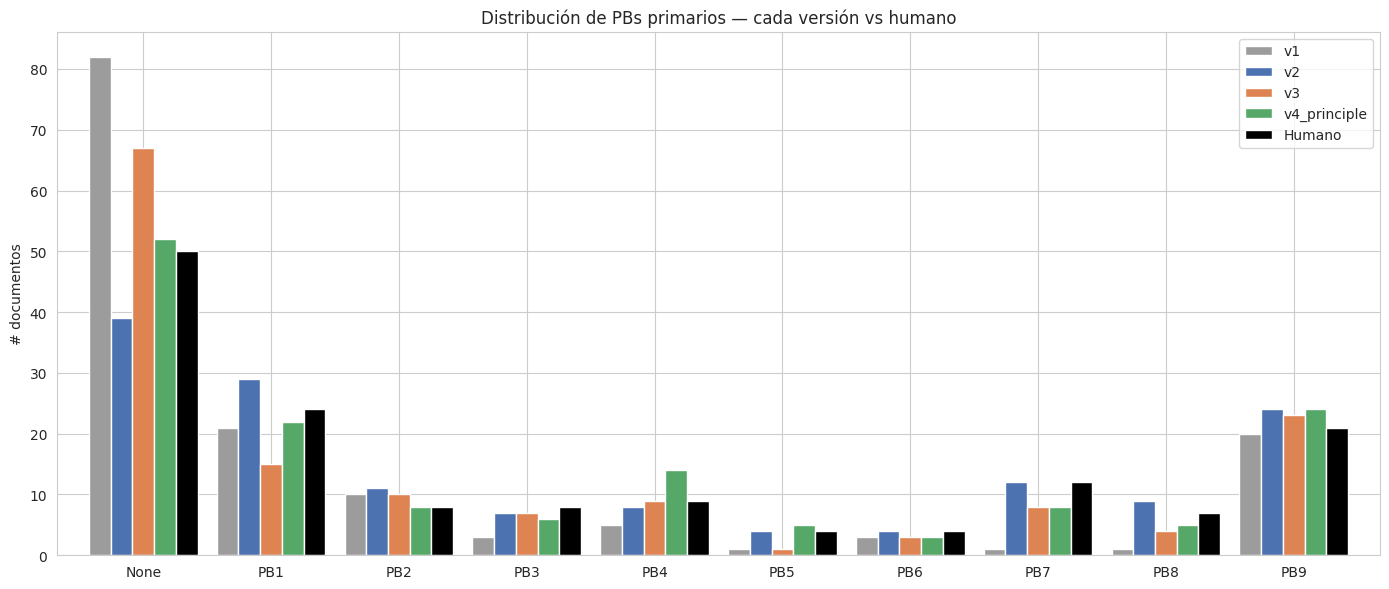

,v1,v2,v3,v4_principle,Humano
None,82,39,67,52,50
PB1,21,29,15,22,24
PB2,10,11,10,8,8
PB3,3,7,7,6,8
PB4,5,8,9,14,9
PB5,1,4,1,5,4
PB6,3,4,3,3,4
PB7,1,12,8,8,12
PB8,1,9,4,5,7
PB9,20,24,23,24,21


In [12]:
dist = pd.DataFrame({v: merged[f'prim_{v}'].value_counts().reindex(PB_LABELS, fill_value=0) for v in available})
dist['Humano'] = merged['human_primary'].value_counts().reindex(PB_LABELS, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
dist.plot(kind='bar', ax=ax, color=[COLORS[v] for v in available] + ['black'], width=0.85)
ax.set_title('Distribución de PBs primarios — cada versión vs humano')
ax.set_ylabel('# documentos'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

display(dist)

**Lectura**: una versión saludable tiene una distribución de barras **paralela** a la de humano. Donde se aleja, ahí hay sesgo (sub o sobre-representación de un PB).

## 10. Calibración: ¿la confianza del LLM correlaciona con acertar?

El LLM auto-reporta `High/Medium/Low` para cada predicción. Un modelo bien calibrado dice "Low" cuando va a fallar y "High" cuando va a acertar.

### Métricas de calibración
- **Acuerdo High/Hit**: en docs marcados como "High", ¿qué % son aciertos?
- Idealmente: High > Medium > Low en tasa de acierto.
- Si la curva es plana, la confianza no informa: tirarla.

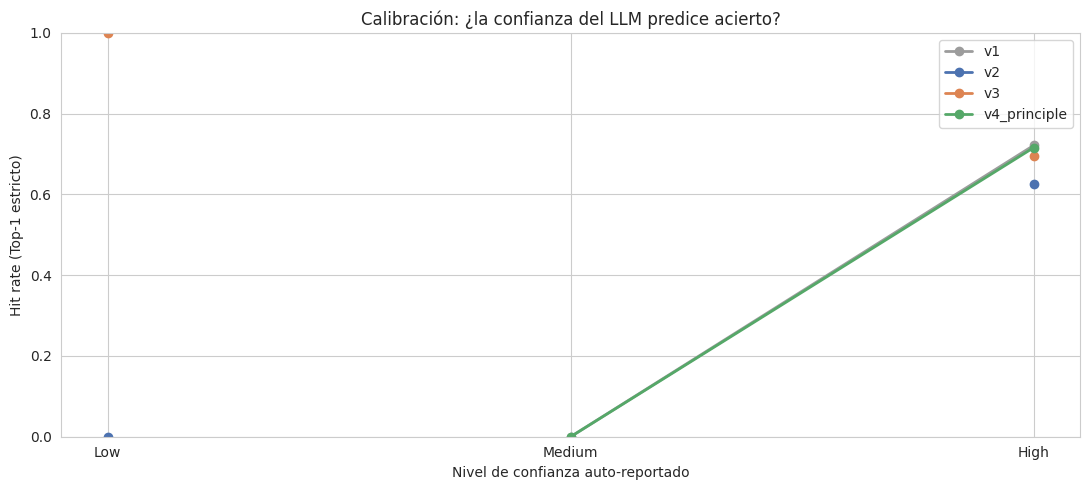

version,v1,v2,v3,v4_principle
conf,,,,
Low,nan%,0.00%,100.00%,nan%
Medium,0.00%,nan%,nan%,0.00%
High,72.13%,62.62%,69.62%,71.58%


In [13]:
calib_rows = []
for v in available:
    if f'conf_{v}' not in merged.columns: continue
    sub = merged.copy()
    sub['hit'] = (sub['human_primary'] == sub[f'prim_{v}']).astype(int)
    for level in ['High', 'Medium', 'Low']:
        msk = sub[f'conf_{v}'] == level
        if msk.sum() > 0:
            calib_rows.append({'version': v, 'conf': level, 'n': int(msk.sum()),
                               'hit_rate': sub.loc[msk, 'hit'].mean()})
calib_df = pd.DataFrame(calib_rows)
if not calib_df.empty:
    fig, ax = plt.subplots(figsize=(11, 5))
    for v in available:
        sub = calib_df[calib_df['version'] == v].set_index('conf').reindex(['Low', 'Medium', 'High'])
        ax.plot(sub.index, sub['hit_rate'], marker='o', label=v, color=COLORS[v], linewidth=2)
    ax.set_ylabel('Hit rate (Top-1 estricto)'); ax.set_xlabel('Nivel de confianza auto-reportado')
    ax.set_title('Calibración: ¿la confianza del LLM predice acierto?')
    ax.legend(); ax.set_ylim(0, 1)
    plt.tight_layout(); plt.show()
    display(calib_df.pivot(index='conf', columns='version', values='hit_rate').reindex(['Low', 'Medium', 'High']).style.format('{:.2%}'))
else:
    print('No hay columna de confianza disponible.')

**Lectura**:
- Curva monótona creciente (Low < Medium < High) → calibración decente.
- Curva plana o decreciente → la confianza es ruido, no la uses para filtrar.
- Si una versión tiene High = 95% pero Low = 80%, está sobre-confiada (todo le parece High).

## 11. Tiempo de inferencia

Variable importante para coste y throughput. Prompts más largos → más tiempo. Prompts con CoT → más tokens generados → más tiempo.

Si v4_principle es 2x más lento que v3, hay que justificar la mejora en calidad para que merezca la pena.

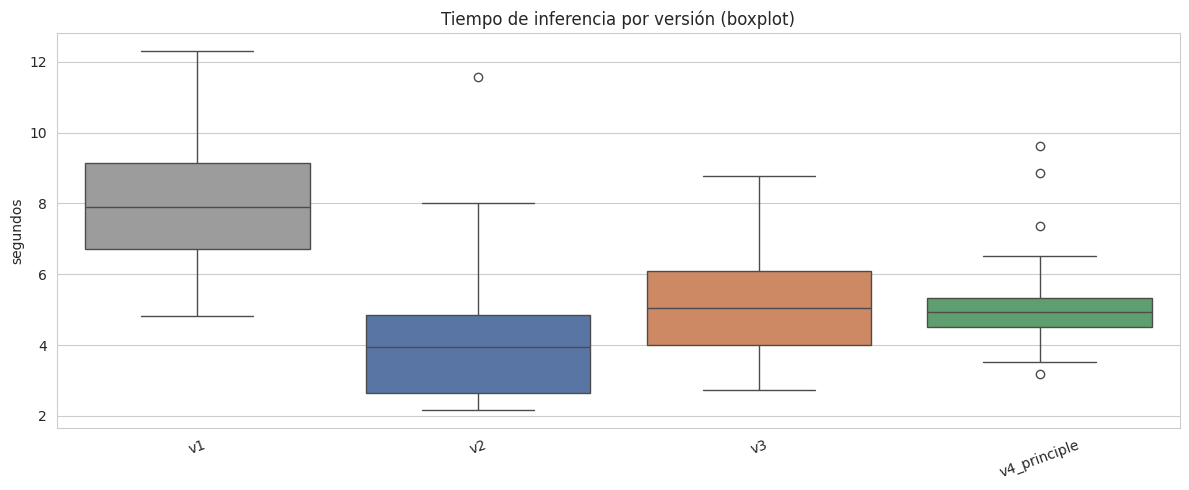

           v1      v2      v3  v4_principle
count  147.00  147.00  147.00        147.00
mean     7.99    3.99    5.08          4.97
std      1.59    1.39    1.32          0.81
min      4.83    2.16    2.72          3.18
25%      6.72    2.63    3.99          4.52
50%      7.89    3.94    5.05          4.93
75%      9.13    4.86    6.10          5.34
max     12.31   11.56    8.77          9.62


In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
data = pd.DataFrame({v: merged[f'time_{v}'] for v in available})
sns.boxplot(data=data, ax=ax, palette=[COLORS[v] for v in available])
ax.set_ylabel('segundos'); ax.set_title('Tiempo de inferencia por versión (boxplot)')
plt.xticks(rotation=20)
plt.tight_layout(); plt.show()
print(data.describe().round(2))

## 12. Documentos donde las versiones discrepan

Útil para análisis cualitativo: estos son los docs donde las distintas iteraciones del prompt cambian el veredicto. Si un doc se etiqueta de 4 formas distintas, es ambiguo de verdad y vale la pena revisarlo manualmente.

In [15]:
prim_cols = [f'prim_{v}' for v in available]
discrep_mask = merged[prim_cols].nunique(axis=1) > 1
discrep = merged[discrep_mask].copy()
print(f'Documentos donde al menos dos versiones discrepan: {len(discrep)} de {len(merged)}')
print()
display(discrep[['doc_id', 'human_primary'] + prim_cols].head(30))

Documentos donde al menos dos versiones discrepan: 63 de 147



,doc_id,human_primary,prim_v1,prim_v2,prim_v3,prim_v4_principle
2,ff6fb1e2be19,PB1,PB1,PB1,None,PB1
4,eaf6d52d5457,PB1,None,PB1,None,PB1
6,ca6e200d678b,PB1,None,PB3,None,PB9
8,5194c7c1714e,PB1,PB1,PB7,None,PB1
9,dbde52e667aa,PB1,None,PB1,None,None
14,84915f5956b8,None,PB2,PB2,None,PB2
15,a31195146871,PB2,PB2,PB2,PB1,PB4
17,66c76ad14a95,PB1,None,None,None,PB1
18,bdf5eac988ad,PB8,None,PB8,PB8,PB8
22,caa0f4f9200b,PB1,PB7,PB7,PB7,PB1


## 13. Análisis cualitativo del razonamiento (v4_principle)

Las métricas cuantitativas dicen *cuánto* acierta. Los razonamientos dicen *cómo*. Para cada modo de fallo de v4_principle, mostramos un ejemplo con el reasoning del modelo, para detectar patrones interpretativos.

In [16]:
target = 'v4_principle' if 'v4_principle' in available else available[-1]
print(f'Análisis cualitativo de la versión: {target}')
print('=' * 70)

if f'reason_{target}' in merged.columns:
    sub = merged.copy()
    sub['hit_strict'] = sub['human_primary'] == sub[f'prim_{target}']
    sub['llm_invented'] = (sub['human_primary'] == 'None') & (sub[f'prim_{target}'] != 'None')
    sub['llm_chickened'] = (sub['human_primary'] != 'None') & (sub[f'prim_{target}'] == 'None')

    def show(title, mask, n=2):
        print(f'\n--- {title} ---')
        for _, r in sub[mask].head(n).iterrows():
            print(f"doc={r['doc_id']} | humano={r['human_pbs']} | LLM={r[f'pbs_{target}']}")
            print(f"  reasoning: {str(r[f'reason_{target}'])[:400]}")
            print()

    show(f'A. Aciertos (n={sub.hit_strict.sum()}). Razonamiento alineado.', sub.hit_strict)
    show(f'B. Positivity Bias (humano=None, LLM=PB). El LLM ve algo que el humano descartó.', sub.llm_invented)
    show(f'C. Falsos Negativos (humano=PB, LLM=None). El LLM se quedó corto.', sub.llm_chickened)
    show('D. Confusión (humano=PBx, LLM=PBy). Tema correcto, PB equivocado.',
         (~sub.hit_strict) & (sub['human_primary'] != 'None') & (sub[f'prim_{target}'] != 'None'))
else:
    print('No hay reasoning disponible para esta versión.')

Análisis cualitativo de la versión: v4_principle

--- A. Aciertos (n=106). Razonamiento alineado. ---
doc=8d8ab7ed834f | humano=['PB1', 'PB4'] | LLM=['PB1', 'PB4']
  reasoning: The abstract models the impact of climate change on soil organic carbon (SOC) and annual net primary production (NPP). The study quantifies changes in SOC under different climate scenarios, focusing explicitly on temperature rise and precipitation patterns. This directly aligns with PB1's core definition of human-driven alteration through greenhouse gas emissions and associated warming.

doc=ff6fb1e2be19 | humano=['PB1', 'PB7'] | LLM=['PB1']
  reasoning: The abstract focuses on the impacts of climate change on wine production, specifically detailing microbial challenges and potential biotechnological solutions. The primary variable being measured is the effect of climate change on microbial proliferation and other quality parameters in winemaking, which directly relates to PB1 (Climate Change) due to its explici

### Cómo usar este bloque

- En **B (Positivity Bias)**: ¿el reasoning está justificando bien o es ruido? Si justifica bien, quizá el humano se equivocó. Si no, el prompt necesita reforzar la regla.
- En **C (Falsos Negativos)**: ¿el reasoning identifica el tema pero rechaza por la regla de exclusión? Si sí, la regla está demasiado tensa.
- En **D (Confusiones)**: el reasoning te dice qué dos PBs el modelo confunde y por qué.

## 14. Veredicto y siguientes pasos

### Cómo concluir si v4_principle es la versión a desplegar

Pareto-superioridad: gana en TODAS las métricas a TODAS las versiones anteriores. Es raro.

**Criterios prácticos** (más realistas):

1. **Mejora en métricas relajadas**: Top-1 relajado, Hit@K, Any overlap, Jaccard suben respecto a v3.
2. **Mantiene True Negative ≥ 70%**: no se vuelve crédulo.
3. **No despeña ningún PB en recall**: ningún PB cae más de 10 puntos respecto a la mejor versión anterior.
4. **Tiempo razonable**: si es >2x más lento que v3 sin ganancia clara, no compensa.

### Si v4_principle gana
- Es la versión candidata. Pasar a evaluación con un panel humano externo (no solo los 146 ya validados).
- Análisis de errores residuales → sirve para v5 o para definir el alcance de uso del modelo.

### Si v4_principle pierde en algo
- Mira la celda 13C/13D: ¿el modelo entiende mal una regla concreta?
- Mira el patrón de falsos positivos (celda 8a): ¿qué PB inventa más? Refuerza la regla de exclusión de ese PB.
- Considera ajustar `temperature` (actualmente 0.0): subirla puede dar más diversidad pero también más alucinación.

### Limitaciones del benchmark
- 146 docs → la incertidumbre estadística es notable. Una diferencia de 3-5 puntos puede ser ruido.
- 1 solo evaluador humano → ground-truth ruidoso.
- El subset puede no representar la diversidad de papers UPV. Si vas a producción, mide en muestra mayor.

# 15. Conclusión final: **v4_principle es la versión a desplegar**

## Los números (147 docs cruzados)

| Métrica | v1 | v2 | v3 | **v4_principle** | mejor |
|---|---|---|---|---|---|
| Top-1 estricto | 58.5% | 63.9% | 64.6% | **72.1%** | v4_p **+7.5 pt** vs v3 |
| Top-1 relajado | 62.6% | 67.3% | 66.7% | **76.2%** | v4_p **+9.5 pt** |
| Hit@K | 50.5% | 72.2% | 61.9% | **74.2%** | v4_p **+12 pt** vs v3 |
| Any overlap | 63.9% | 68.7% | 68.0% | **77.6%** | v4_p **+9.6 pt** |
| Jaccard | 0.581 | 0.594 | 0.596 | **0.688** | v4_p **+0.09** |
| Exact Match | 53.1% | 50.3% | 52.4% | **60.5%** | v4_p **+8 pt** |
| True Negative | **84.0%** | 54.0% | 78.0% | 76.0% | v1 (pero ver abajo) |
| Positivity Bias ↓ | **16.0%** | 46.0% | 22.0% | 24.0% | v1 |
| Falsos Negativos ↓ | 41.2% | **12.4%** | 28.9% | 14.4% | v2 (pero ver abajo) |

**v4_principle gana las 6 métricas de acierto y queda 2.º en las 3 de sesgo.** Esa es exactamente la firma de una mejora real, no un trade-off ganador-perdedor.

## Por qué v4_principle gana de verdad y no por suerte

**1. Comparación pareada v4_principle vs v3** (la antigua referencia):
- 15 documentos donde **v4_p acierta y v3 falla**.
- 4 documentos donde v3 acierta y v4_p falla.
- Ratio 15:4 → mejora neta de **+11 docs / 147 = +7.5 puntos**. Confirma el Top-1 estricto.

**2. Es la única versión equilibrada en los dos modos de fallo**:
- **v1**: rigorosa (TN 84%) pero **se acobarda** → 40 falsos negativos. No detecta PB7 (recall 0%).
- **v2**: pesca todo (Hit@K 72%) pero **delira** → 46% positivity bias, 23 falsos positivos sobre 50 docs irrelevantes. **Inutilizable en producción**.
- **v3**: corrigió la postura de v2 pero a costa de perder docs (FN 28.9%, recall PB1 cayó a 41.7%).
- **v4_principle**: TN 76% (alto) **y** FN 14% (bajo). Es el único cuadrante "no inventa **y** no se acobarda".

**3. Recall por PB**: v4_principle gana o empata en 6 de 9 PBs frente a v3. Donde pierde (PB5/PB7/PB8 con n=4-12) la diferencia es ≤ 0.15 y v2 las gana solo gracias a su sobre-etiquetado masivo.

## El asterisco honesto

- **PB5 (n=4) y PB6 (n=4)**: tamaño muestral ridículo. Cualquier conclusión sobre estos PBs individuales es ruido estadístico.
- **v2 supera en PB3/PB7/PB8 individuales**: pero su 46% de positivity bias lo descalifica como sistema. Si etiquetas TODO siempre acertarás más en clases minoritarias.
- **v1 sigue ganando en True Negative (84% vs 76%)**: su precio son 26 falsos negativos extra. No compensa.

## Recomendación operativa

| Caso de uso | Versión a usar |
|---|---|
| **Producción (curado de papers UPV)** | **v4_principle** |
| Recall-first (no perder un paper relevante) | v2 + filtro humano posterior |
| Precision-first (cero falsos positivos a costa de cobertura) | v1 |

Para el flujo principal: **v4_principle**. Es Pareto-superior a v3 (mejor en todo lo importante, ~igual en el resto), y la única que combina rigor y cobertura. La siguiente iteración (un v5) debería atacar **PB5, PB7 y PB8** específicamente — son donde el prompt aún no expone bien las distinciones, y donde la incertidumbre estadística sigue siendo notable.